In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

/Users/tobiasmanwaring/Documents/UCL/Repos/Other/trTesting/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,12_ema,27_ema,MACD,Signal,MACD_hist,BB_SMA,BB_STD,Upper_Band,Lower_Band,MACD_Strategy,BB_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
7341,427.451019,427.460517,422.014082,423.133727,64736900,416.561691,412.945586,3.616105,1.623380,1.992724,410.451292,10.435530,420.886822,400.015763,NaN,NaN,NaN,0,NaN,NaN
7342,429.538483,429.813660,425.496339,428.086731,77101300,418.619765,414.447601,4.172164,2.137883,2.034282,411.224406,11.258522,422.482928,399.965884,1.0,-1.0,0.0,0,0.004884,0.000000
7343,432.593811,432.593811,427.042986,428.940702,68529800,420.825523,416.059449,4.766073,2.667428,2.098645,412.203259,12.231555,424.434815,399.971704,1.0,-1.0,0.0,0,0.012031,0.000000
7344,437.945435,438.438859,433.798929,436.493683,86581500,423.517077,417.970243,5.546834,3.246729,2.300105,413.764214,13.429229,427.193442,400.334985,1.0,-1.0,0.0,0,0.024551,0.000000
7345,435.241150,437.613295,433.125186,436.797262,79666900,425.354115,419.454541,5.899574,3.779815,2.119759,414.815837,14.263465,429.079302,400.552372,1.0,-1.0,0.0,0,0.018225,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8317,681.750000,686.280029,677.520020,681.690002,96267500,687.911721,688.116626,-0.204905,1.026070,-1.230975,689.145996,5.704369,694.850366,683.441627,-1.0,1.0,0.0,0,0.594920,-0.060426
8318,682.849976,684.940002,675.780029,680.140015,81354700,687.132991,687.740436,-0.607445,0.699367,-1.306813,688.705496,5.838600,694.544096,682.866896,-1.0,1.0,0.0,0,0.597493,-0.060426
8319,686.289978,689.150024,682.830017,684.020020,73570300,687.003297,687.636832,-0.633535,0.432787,-1.066322,689.140994,5.261384,694.402378,683.879610,-1.0,1.0,0.0,0,0.605541,-0.060426
8320,684.479980,686.179993,681.549988,683.840027,58649400,686.615094,687.411343,-0.796249,0.186980,-0.983228,689.094992,5.299697,694.394689,683.795295,-1.0,0.0,-1.0,0,0.601306,-0.060426


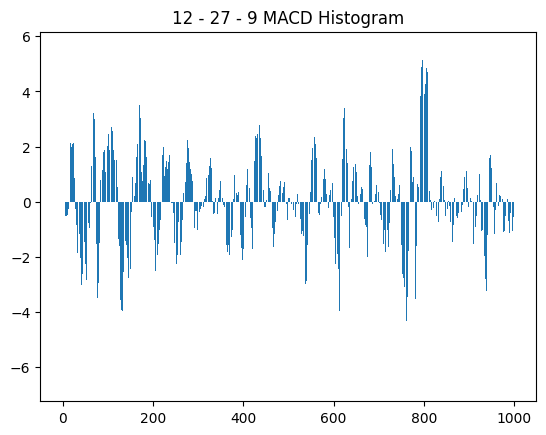

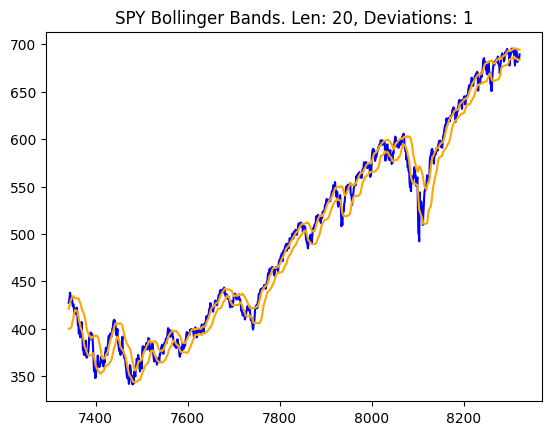

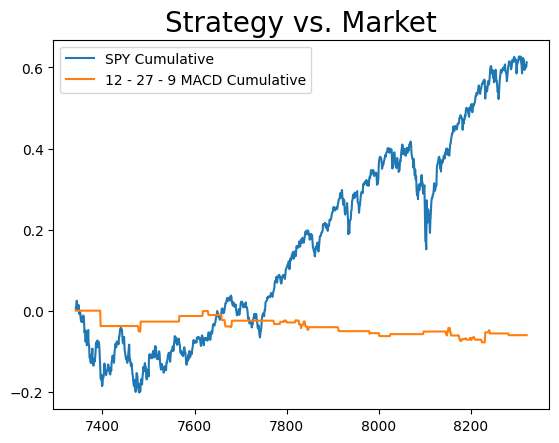

In [2]:
TICKER = 'SPY'
INTERVAL='1d'

if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

MACD_FAST = 12
MACD_SLOW = 27
MACD_SPAN = 9
BB_LEN = 20
DEVS = 1

LOOKBACK = 1000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    df = df.reset_index(drop=True)

    return df.iloc[-lookback:, :]

def add_MACD(df, fast=MACD_FAST, slow=MACD_SLOW, span=MACD_SPAN):

    df[f'{fast}_ema'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ema'] = df['Close'].ewm(span=slow).mean()

    df[f'MACD'] = df[f'{fast}_ema'] - df[f'{slow}_ema']

    df['Signal'] = df['MACD'].ewm(span=span).mean()

    df['MACD_hist'] = df['MACD'] - df['Signal']

    plt.bar(x=range(len(df)), height=df['MACD_hist'])
    plt.title(f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Histogram')

    return df

def add_MACD_strategy(df):

    df['MACD_Strategy'] = 0
    df['MACD_Strategy'] = np.where(df['MACD_hist'] > 0, 1, -1)
    df['MACD_Strategy'] = df['MACD_Strategy'].shift(1)
    
    return df

def add_bollinger_bands(df, devs=DEVS, bb_len=BB_LEN):

    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band'] = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band'] = df['BB_SMA'] - (devs * df['BB_STD'])

    df = df.dropna()

    plt.figure()
    plt.plot(df['Close'], color='blue')
    plt.plot(df['Upper_Band'], color='orange')
    plt.plot(df['Lower_Band'], color='orange')

    plt.title(f'{TICKER} Bollinger Bands. Len: {BB_LEN}, Deviations: {DEVS}');

    return df

def add_BB_strategy(df):
    df['BB_Strategy'] = 0
    df['BB_Strategy'] = np.where(
        df['Close'] > df['Upper_Band'], -1, 
        np.where(df['Close'] < df['Lower_Band'], 1, 0)
        )
    
    df['BB_Strategy'] = df['BB_Strategy'].shift(1)
    
    return df

def add_full_strategy(df):

    df['Full_Strategy'] = df['MACD_Strategy'] + df['BB_Strategy']

    df['Strategy'] = np.where(df['Full_Strategy'] == 2, 1, 
                     np.where(df['Full_Strategy'] == -2, -1, 0))

    return df

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Cumulative'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_MACD(df)
    df = add_bollinger_bands(df)
    df = add_MACD_strategy(df)
    df = add_BB_strategy(df)
    df = add_full_strategy(df)
    df = test_strategy(df)

    return df

df = main()
df